AI Triage Assistant

This project develops a decision-support tool that takes a user's described symptoms and classifies them into an Index or urgency level (e.g., Red, Yellow, Green). It utilizes NLP to parse medical descriptions and a classification head to recommend the appropriate level of care. This project highlights the intersection of AI and healthcare, focusing on resource optimization and patient safety.

Data: https://huggingface.co/datasets/syntech-ai/medical-triage-500

Video: https://youtu.be/Cy-pb17BWf0

In [13]:
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input


In [14]:
try:
    health = pd.read_csv('cleanhealthdata.csv')
    
    # Feature engineering - Including Context and Symptom Count
    health['patient_profile'] = (
        "Patient is a " + health['patient.age'].astype(str) + " year old " + 
        health['patient.gender'] + ". Symptoms started " + 
        health['presentation.onset'] + " while " + 
        health['presentation.context'] + " and have lasted for " + 
        health['presentation.duration'] + ". Symptoms: " + 
        health['presentation.symptoms']
    )
    print("Data loaded. 'Smart Profile' created with Context and Onset logic.")
except Exception as e:
    print(f"Error: Ensure 'cleanhealthdata.csv' is in your folder. Details: {e}")

Data loaded. 'Smart Profile' created with Context and Onset logic.


In [15]:
#NLP Vect
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(health['patient_profile'])
y_labels = health['Colour']

X_train_tfidf, X_test_tfidf, y_train_text, y_test_text = train_test_split(
    X_tfidf, y_labels, test_size=0.2, random_state=42
)


In [16]:
#Encoding
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_labels)
y_categorical = to_categorical(y_encoded)
y_train_cat, y_test_cat = train_test_split(y_categorical, test_size=0.2, random_state=42)

X_train_keras = X_train_tfidf.toarray()
X_test_keras = X_test_tfidf.toarray()

In [40]:
#building the model 
model = Sequential([
    Input(shape=(X_train_keras.shape[1],)), 
    Dense(128, activation='relu'), 
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


print("\nTraining Triage Model")
model.fit(X_train_keras, y_train_cat, epochs=30, batch_size=10, verbose=1)


Training Triage Model
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step - accuracy: 0.4500 - loss: 1.0590 
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - accuracy: 0.5875 - loss: 0.9646
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - accuracy: 0.6400 - loss: 0.8364
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step - accuracy: 0.6775 - loss: 0.6750
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step - accuracy: 0.7325 - loss: 0.5674
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - accuracy: 0.8150 - loss: 0.4574
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - accuracy: 0.8550 - loss: 0.3863
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - accuracy: 0.8775 - loss: 0.3275
Epoch 9/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - accuracy: 0.9450 - loss: 0.2396
Epoch 10/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - accuracy: 0.9475 - loss: 0.2150
Epoch 11/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - accuracy: 0.9600 - loss: 0.1800
Epoch 12/30
40/40 ━━━━━━━━━━

In [41]:
y_pred_probs = model.predict(X_test_keras, verbose=0)
y_pred_labels = encoder.inverse_transform(np.argmax(y_pred_probs, axis=1))
print(f"\nFinal Model Accuracy: {accuracy_score(y_test_text, y_pred_labels)*100:.2f}%")

# Print the report on acc
print("\nClassification Report:")
print(classification_report(y_test_text, y_pred_labels))



Final Model Accuracy: 89.00%

Classification Report:
              precision    recall  f1-score   support

       green       0.90      0.69      0.78        13
         red       0.93      0.96      0.94        53
      yellow       0.83      0.85      0.84        34

    accuracy                           0.89       100
   macro avg       0.89      0.84      0.86       100
weighted avg       0.89      0.89      0.89       100



In [42]:
# get the values for each of the selections to a list
genders = sorted(health['patient.gender'].unique().tolist())
onsets = sorted(health['presentation.onset'].unique().tolist())
durations = sorted(health['presentation.duration'].unique().tolist())
contexts = sorted(health['presentation.context'].unique().tolist())

In [43]:
#designing the menus/dropdowns for the traiger
age_in = widgets.IntText(value=30, description='Age:')
sex_in = widgets.Dropdown(options=genders, description='Gender:')
onset_in = widgets.Dropdown(options=onsets, description='Onset:')
context_in = widgets.Dropdown(options=contexts, description='Context:')
dur_in = widgets.Dropdown(options=durations, description='Duration:')
sym_in = widgets.Text(placeholder='e.g., chest pain, cough', description='Symptoms:')
btn = widgets.Button(description='Analyze Patient Risk', button_style='danger')
out = widgets.Output()

In [44]:
def run_triage(b):
    """
    Executes the inference pipeline and updates the interactive UI.

    Process Flow:
    1. Template Matching: Construct a clinical narrative from UI widget values 
       to match the 'patient_profile' format used during training.
    2. Vectorization: Transforms the raw string into a numerical TF-IDF 
       feature vector using the pre-fitted 'tfidf' object.
    3. Prediction: Feeds the vector into the Neural Network to obtain a 
       Softmax probability distribution across triage classes.
    4. Post-processing: Decodes the highest probability index back into a 
       human-readable color label (Red, Yellow, Green).
    5. UI Update: Clears previous results and displays the recommendation, 
       confidence score, and clinical urgency instructions.

    Args:
        b (widgets.Button): The button instance that triggered the event.
    """
    with out:
        clear_output()
        user_profile = (
            f"Patient is a {age_in.value} year old {sex_in.value}. "
            f"Symptoms started {onset_in.value} while {context_in.value} "
            f"and have lasted for {dur_in.value}. Symptoms: {sym_in.value.lower()}"
        )
        
        vec = tfidf.transform([user_profile]).toarray()
        probs = model.predict(vec, verbose=0)[0]
        winner = np.argmax(probs)
        result = encoder.inverse_transform([winner])[0]
        
        print(f"Narrative Generated: \"{user_profile}\"")
        print("-" * 60)
        print(f"AI RECOMMENDATION: {result.upper()}")
        print(f"CONFIDENCE SCORE: {probs[winner]*100:.2f}%")
        
        if result == 'red':
            print("\n🚨 CRITICAL: Immediate Emergency Intervention Required.")
        elif result == 'yellow':
            print("\n⚠️ URGENT: Clinical Evaluation required within 2-4 hours.")
        else:
            print("\n✅ ROUTINE: Low-risk symptoms. Advise primary care follow-up.")

btn.on_click(run_triage)

print("\n" + "="*50)
print("  AI-DRIVEN CLINICAL TRIAGE DECISION SYSTEM")
print("="*50)
display(age_in, sex_in, onset_in, context_in, dur_in, sym_in, btn, out)


  AI-DRIVEN CLINICAL TRIAGE DECISION SYSTEM


IntText(value=30, description='Age:')

Dropdown(description='Gender:', options=('female', 'male'), value='female')

Dropdown(description='Onset:', options=('gradual', 'sudden'), value='gradual')

Dropdown(description='Context:', options=('at rest', 'during activity', 'while walking'), value='at rest')

Dropdown(description='Duration:', options=('1 day', '1 week', '2 hours', '3 days', '6 hours'), value='1 day')

Text(value='', description='Symptoms:', placeholder='e.g., chest pain, cough')

Button(button_style='danger', description='Analyze Patient Risk', style=ButtonStyle())

Output()

In [45]:
# Fixed version to include validation and capture history
history = model.fit(
    X_train_keras, 
    y_train_cat, 
    epochs=30, 
    batch_size=10, 
    verbose=1,
    validation_data=(X_test_keras, y_test_cat) # This provides val_loss and val_accuracy
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9975 - loss: 0.0157 - val_accuracy: 0.8500 - val_loss: 0.3932
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - accuracy: 0.9950 - loss: 0.0184 - val_accuracy: 0.8900 - val_loss: 0.3807
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 0.9975 - loss: 0.0168 - val_accuracy: 0.8700 - val_loss: 0.4039
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - accuracy: 1.0000 - loss: 0.0125 - val_accuracy: 0.8900 - val_loss: 0.4124
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step - accuracy: 1.0000 - loss: 0.0125 - val_accuracy: 0.8900 - val_loss: 0.4428
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - accuracy: 0.9975 - loss: 0.0158 - val_accuracy: 0.8900 - val_loss: 0.3858
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step - accuracy: 0.9975 - loss: 0.0089 - val_accuracy: 0.8800 - val_loss: 0.3900
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step - accuracy: 1.0000 - loss: 0.0126 - val_accuracy: 0.89

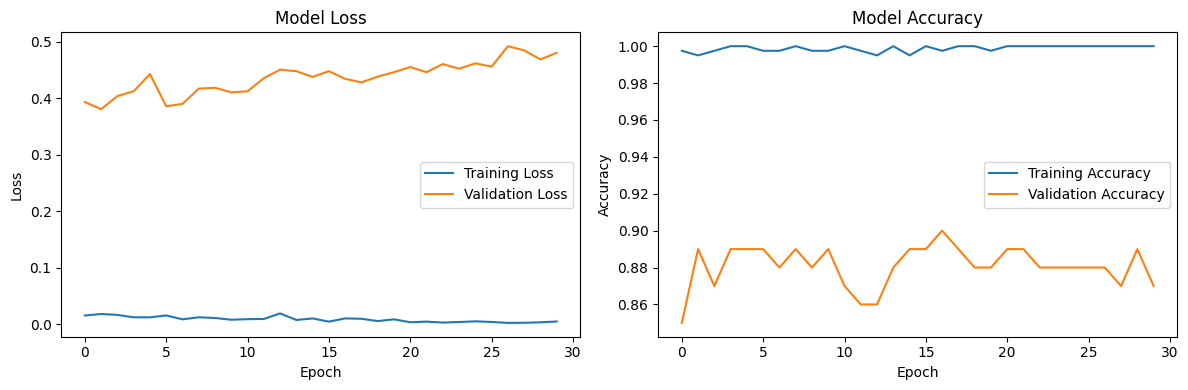

In [46]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Loss
ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Plot 2: Accuracy
ax2.plot(history.history['accuracy'], label='Training Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()